In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("shoe_sales.csv")
df.head()

,date,brand,sold_qty
0,9/1/2023,Nike,24.0
1,9/1/2023,Adidas,14.0
2,9/2/2023,Nike,21.0
3,9/2/2023,Adidas,12.0
4,9/3/2023,Nike,18.0


In [6]:
df.shape

(60, 3)

In [7]:
df.describe()

,sold_qty
count,58.000000
mean,27.482759
std,88.519844
min,7.000000
25%,12.250000
50%,16.000000
75%,19.750000
max,689.000000


In [15]:
df[df.sold_qty>19.75].shape

(15, 3)

In [16]:
15/60

0.25

In [17]:
df[df.sold_qty>19.75]

,date,brand,sold_qty
0,9/1/2023,Nike,24.0
2,9/2/2023,Nike,21.0
6,9/4/2023,Nike,22.0
8,9/5/2023,Nike,20.0
10,9/6/2023,Nike,23.0
16,9/9/2023,Nike,25.0
20,9/11/2023,Nike,23.0
23,9/12/2023,Adidas,689.0
26,9/14/2023,Nike,22.0
30,9/16/2023,Nike,21.0


#### (1) Nike Analysis

In [19]:
df_nike = df[df.brand=="Nike"]

In [20]:
df_nike.shape

(30, 3)

In [21]:
df_nike.describe()

,sold_qty
count,28.000000
mean,19.642857
std,3.117624
min,14.000000
25%,17.000000
50%,19.500000
75%,22.000000
max,25.000000


In [33]:
val = round(df_nike.sold_qty.median())
val

20

In [28]:
df_nike[df_nike.sold_qty.isnull()]

,date,brand,sold_qty
32,9/17/2023,Nike,NaN
48,9/25/2023,Nike,NaN


In [40]:
df_nike.fillna({'sold_qty': val}, inplace=True)

,date,brand,sold_qty
0,9/1/2023,Nike,24.0
2,9/2/2023,Nike,21.0
4,9/3/2023,Nike,18.0
6,9/4/2023,Nike,22.0
8,9/5/2023,Nike,20.0
10,9/6/2023,Nike,23.0
12,9/7/2023,Nike,19.0
14,9/8/2023,Nike,17.0
16,9/9/2023,Nike,25.0
18,9/10/2023,Nike,14.0


In [41]:
df_nike.loc[[32, 48]]

,date,brand,sold_qty
32,9/17/2023,Nike,20.0
48,9/25/2023,Nike,20.0


In [48]:
df_nike.sold_qty.sum()

np.float64(590.0)

In [50]:
df_adidas = df[df.brand == 'Adidas']
df_adidas.head()

,date,brand,sold_qty
1,9/1/2023,Adidas,14.0
3,9/2/2023,Adidas,12.0
5,9/3/2023,Adidas,11.0
7,9/4/2023,Adidas,13.0
9,9/5/2023,Adidas,10.0


In [44]:
df_adidas.shape

(30, 3)

In [45]:
df_adidas.describe()

,sold_qty
count,30.000000
mean,34.800000
std,123.602366
min,7.000000
25%,10.000000
50%,12.500000
75%,15.000000
max,689.000000


In [47]:
round(df_adidas.sold_qty.median())

12

In [49]:
df_adidas.sold_qty.sum()

np.float64(1044.0)

In [51]:
df_adidas.sold_qty.quantile([0.95])

0.95    18.55
Name: sold_qty, dtype: float64

In [52]:
df_adidas[df_adidas.sold_qty>18.55]

,date,brand,sold_qty
23,9/12/2023,Adidas,689.0
39,9/20/2023,Adidas,19.0


In [53]:
def plot_qty():
    plt.figure(figsize=(15, 6))
    
    dates = df_nike['date']
    
    plt.plot(dates, df_nike['sold_qty'], marker='o', label='Nike', color='blue')
    plt.plot(dates, df_adidas['sold_qty'], marker='o', label='Adidas', color='red')
    
    plt.xlabel('Date')
    plt.ylabel('Total Qty Sold')
    plt.title('Daily Sales Qty for Nike and Adidas in September 2023')
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.show()

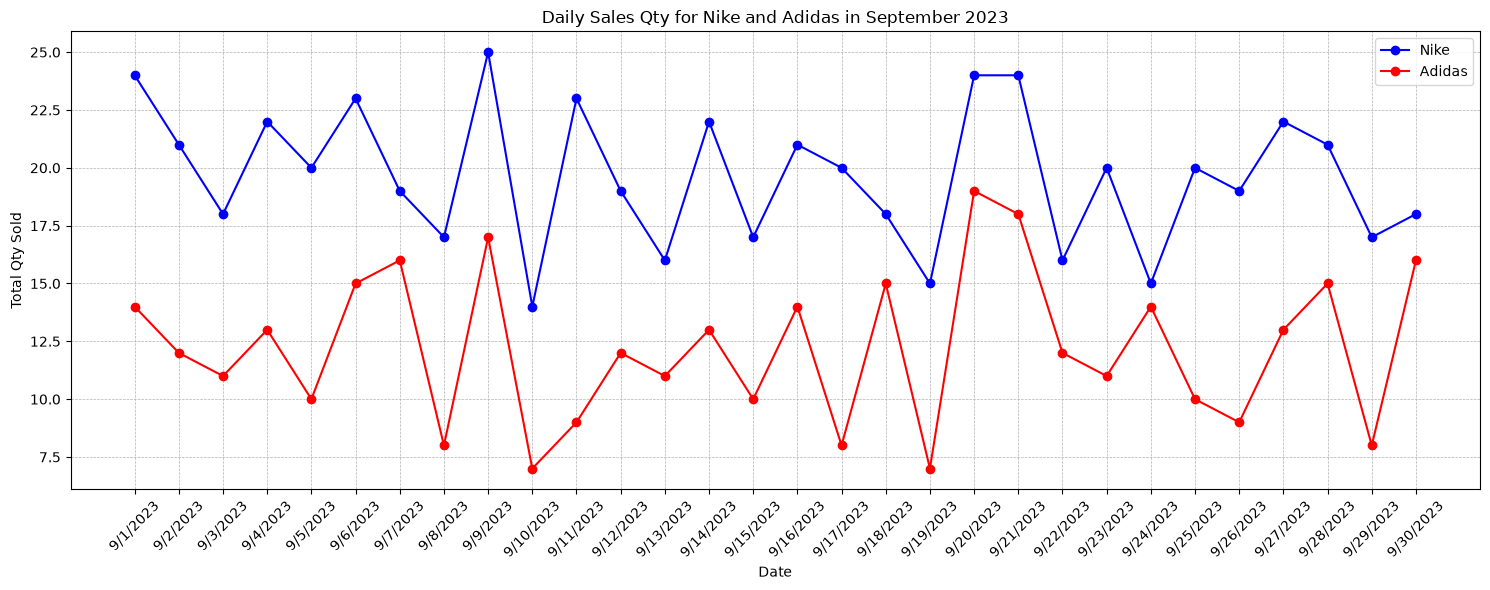

In [64]:
plot_qty()

In [57]:
val = round(df_adidas.sold_qty.median())
val

12

In [63]:
df_adidas.replace({ 'sold_qty': {689: val}}, inplace=True)

,date,brand,sold_qty
1,9/1/2023,Adidas,14.0
3,9/2/2023,Adidas,12.0
5,9/3/2023,Adidas,11.0
7,9/4/2023,Adidas,13.0
9,9/5/2023,Adidas,10.0
11,9/6/2023,Adidas,15.0
13,9/7/2023,Adidas,16.0
15,9/8/2023,Adidas,8.0
17,9/9/2023,Adidas,17.0
19,9/10/2023,Adidas,7.0
